<h2>Ejercicio 3

In [1]:
import pandas as pd
from wget import download
from os import path, listdir

In [ ]:
#descargamos si no existen
if not path.exists("catalogo_streaming_argentina_2024.xlsx"):
    download("https://ignaciorlando.github.io/datasets/data-science/catalogo_streaming_argentina_2024.xlsx")
else:
    print("No vamos a bajar el archivo porque ya existe")

df = pd.read_excel('catalogo_streaming_argentina_2024.xlsx')

In [ ]:
df['title'] = df['title'].astype('string')
df[['year_init', 'year_end']] = df['year_range'].astype(str).str.split('_', expand=True)
df['year_init'] = df['year_init'].astype(float)
df['year_end'] = df['year_end'].astype(float)
df = df.drop(columns=['year_range'])

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19817 entries, 0 to 19816
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           19817 non-null  string 
 1   platform        19817 non-null  str    
 2   type            19817 non-null  str    
 3   imdbVotes       17854 non-null  float64
 4   imdbScore       17927 non-null  float64
 5   tmdbPopularity  19538 non-null  float64
 6   tmdbScore       18954 non-null  float64
 7   runtime         19817 non-null  int64  
 8   genres          19665 non-null  str    
 9   director        14626 non-null  str    
 10  url             19817 non-null  str    
 11  year_init       19817 non-null  float64
 12  year_end        10925 non-null  float64
dtypes: float64(6), int64(1), str(5), string(1)
memory usage: 2.0 MB


In [37]:
df.head()

,title,platform,type,imdbVotes,imdbScore,tmdbPopularity,tmdbScore,runtime,genres,director,url,year_init,year_end,votes_scaled,rnk_rating
0,Cadena perpetua,Max,MOVIE,2906253.0,9.3,159.594,8.705,142,"Drama, Crimen",Frank Darabont,https://play.max.com/movie/9b4dacba-2f80-4272-...,1900.0,2002.0,10.000000,9.510000
1,El caballero oscuro,Max,MOVIE,2893241.0,9.0,111.674,8.516,152,"Misterio & Suspense, Drama, Acción & Aventura,...",Christopher Nolan,https://play.max.com/movie/52217243-a137-45d6-...,2003.0,2010.0,9.996572,9.298972
2,Origen,Max,MOVIE,2570263.0,8.8,139.644,8.369,148,"Ciencia ficción, Acción & Aventura, Misterio &...",Christopher Nolan,https://play.max.com/movie/14552c93-d318-4563-...,2003.0,2010.0,9.906149,9.131845
3,El club de la lucha,Disney Plus,MOVIE,2345071.0,8.8,108.297,8.400,139,Drama,David Fincher,https://disneyplus.bn5x.net/c/1206980/705874/9...,1998.0,2004.0,9.836105,9.110831
4,El club de la lucha,Netflix,MOVIE,2345071.0,8.8,108.297,8.400,139,Drama,David Fincher,http://www.netflix.com/title/26004747,1995.0,2005.0,9.836105,9.110831


In [15]:
df.describe(include='all')

,title,platform,type,imdbVotes,imdbScore,tmdbPopularity,tmdbScore,runtime,genres,director,url,year_init,year_end
count,19817,19817,19817,1.785400e+04,17927.000000,19538.000000,18954.000000,19817.000000,19665,14626,19817,19817.000000,10925.000000
unique,18008,6,2,NaN,NaN,NaN,NaN,NaN,4189,8812,19062,NaN,NaN
top,Perdida,Netflix,MOVIE,NaN,NaN,NaN,NaN,NaN,Documental,Steven Spielberg,http://www.netflix.com/title/81665878,NaN,NaN
freq,5,7109,14060,NaN,NaN,NaN,NaN,NaN,1277,27,2,NaN,NaN
mean,NaN,NaN,NaN,4.838858e+04,6.399520,41.195589,6.461363,80.542867,NaN,NaN,NaN,2001.697532,2012.569245
std,NaN,NaN,NaN,1.488473e+05,1.200258,131.031366,1.254487,37.092943,NaN,NaN,NaN,38.930335,8.020073
min,NaN,NaN,NaN,5.000000e+00,1.100000,0.001000,0.500000,0.000000,NaN,NaN,NaN,1900.000000,1997.000000
25%,NaN,NaN,NaN,4.620000e+02,5.700000,5.433250,5.889500,48.000000,NaN,NaN,NaN,2009.000000,2010.000000
50%,NaN,NaN,NaN,2.849500e+03,6.500000,14.428500,6.600000,89.000000,NaN,NaN,NaN,2017.000000,2015.000000
75%,NaN,NaN,NaN,2.196975e+04,7.300000,33.312500,7.273750,105.000000,NaN,NaN,NaN,2021.000000,2018.000000


<h3>Inciso a)

In [ ]:
import sweetviz as sv
repo = sv.analyze(df)
repo.show_html("reporte_platforms.html")
#repo.show_notebook()


<span style="color:violet">¿Qué se puede decir de la distribución de estos valores? Relacionar con lo obtenido usando el método describe() de Pandas en el práctico anterior</span>


<span style="color:orange">**Plataforma**</span>
<p>Podemos ver que el 78% del contenido audiovisual se reparte entre Netflix y Amazon Prime video.


<span style="color:orange">**Tipo**</span>
<p>Podemos ver que el 70% del contenido audiovisual es del tipo pelicula.

<span style="color:orange">**imdbVotes**</span>
<p>Tenemos una distribucion con sesgo a derecha donde el 95% de la cantidad de votos se ubican entre 5 y 300 mil votos (el minimo de 5 no lo da el reporte, lo da el descriptor de pandas). Ademas, el reporte no nos esta generando bien los cuartiles debido a la diversidad de los valores en la escala, por lo que mediante el descriptor podemos decir que el 75% se concentra entre 5 y 21.900 votos.

<span style="color:orange">**imdbScore**</span>
<p>Podemos ver que se sigue una distribucion normal un 50% tiene entre 1.10 y 6.5 de puntos y el otro 50% tiene entre 6.5 y 9.7 puntos.

<span style="color:orange">**tmdbPopularity**</span>
<p>Tenemos una distribucion con sesgo a derecha donde el 75% se concentra entre 0 y 3 puntos de popularidad. Luego, tenemos outliers que nos tiran la media hacia arriba donde el 25% restante se concentra entre 33 y 4174 puntos de popularidad.

<span style="color:orange">**tmdbScore**</span>
<p>Tenemos una distribucion normal similiar a la de imdbScore.

<span style="color:orange">**runtime**</span>
<P>Tenemos una distribucion normal donde el 50% tiene un tiempo de duracion de entre 0 minutos y 89 minutos.

<span style="color:orange">**anio de inicio transmicion**</span>
<p>Podemos ver que el 50% de las peliculas almacenadas fueron comenzadas a transmitir entre 2017 y 2024 donde el otro 50% se distribuye entre 1900 y 2017.

<span style="color:orange">**anio fin de transmicion**</span>
<p>Podemos ver que el 55% de las peliculas/series ya finalizaron y que el 45% restante aun sigue en vigencia de transmicion. Dentro de las que finalizaron, podemos ver que en el anio donde finalizaron mas es el anio 2017 con el 14.8%.

<h3>Inciso b) y c)<h3>

<span style="color:violet">Analizando las columnas del conjunto, plantear al menos 3 hipótesis diferentes que analicen la relación entre dos variables y estudiar las hipótesis calculando la correlación entre variables e imprimiendo scatter plots. ¿Son verosímiles estas hipótesis? Justificar.</span>

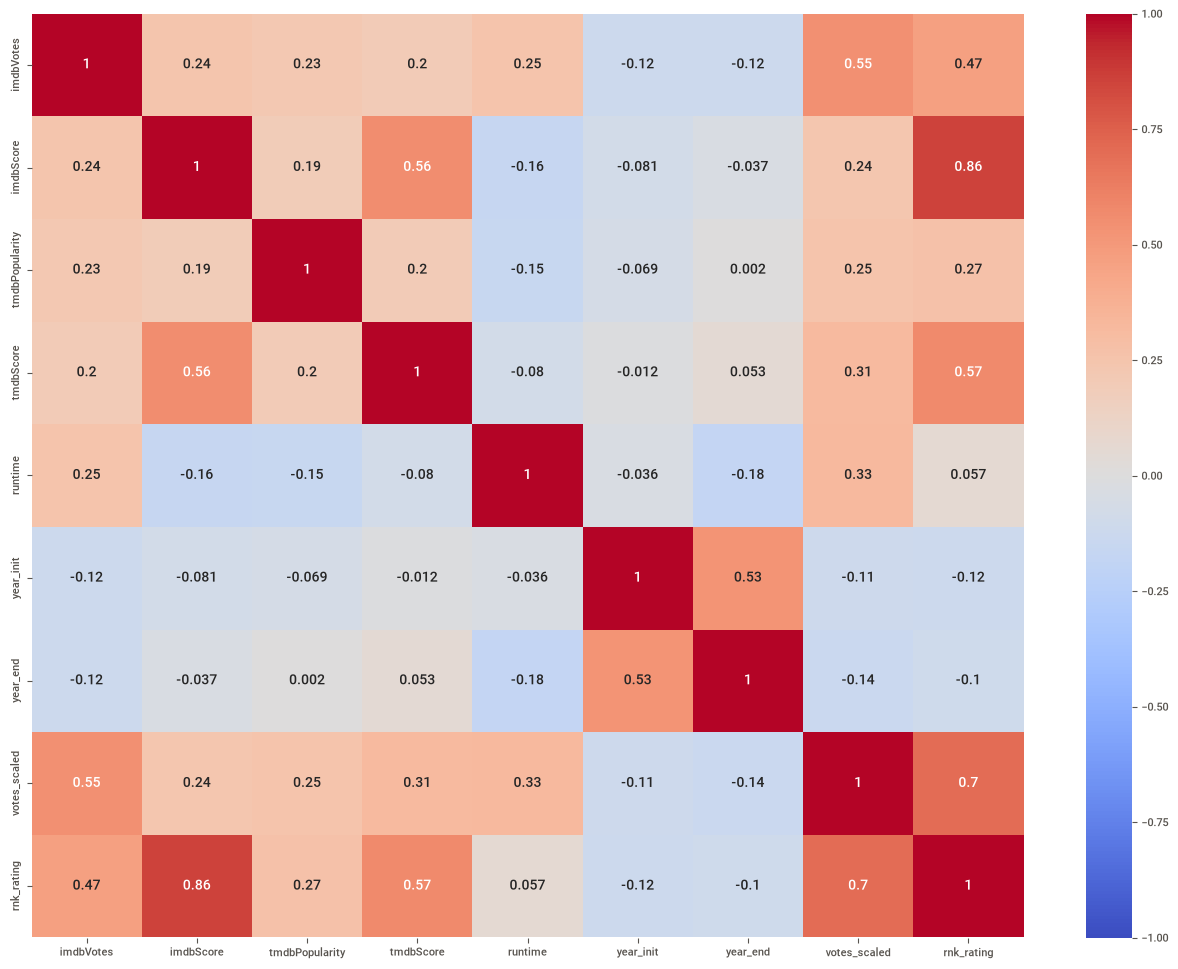

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr(numeric_only=True)

# imprimimos la matriz como un heatmap
plt.figure(figsize=(16,12))
sns.heatmap(correlation_matrix, vmin=-1.0, vmax=1.0, center=0.0, annot=True, cmap= 'coolwarm')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
var_1 = 'rnk_rating'
var_2 = 'runtime'

#creamos el scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(df[var_1], df[var_2])
plt.xlabel(var_1)
plt.ylabel(var_2)
plt.title("Relación entre {} y {}".format(var_1, var_2))

# calcular la correlación de Pearson usando SciPy
coeficiente_correlacion, _ = stats.pearsonr(df[var_1], df[var_2])
print(coeficiente_correlacion)
# agregar la leyenda con el valor del coeficiente de correlación
plt.legend([f"Correlación: {coeficiente_correlacion:.4f}"], loc="upper left")

# Mostrar el gráfico
plt.grid(True)
plt.show()

- <span style="color:orange">Existe una relacion entre el tmdbPopularity y la duracion del contenido </span>

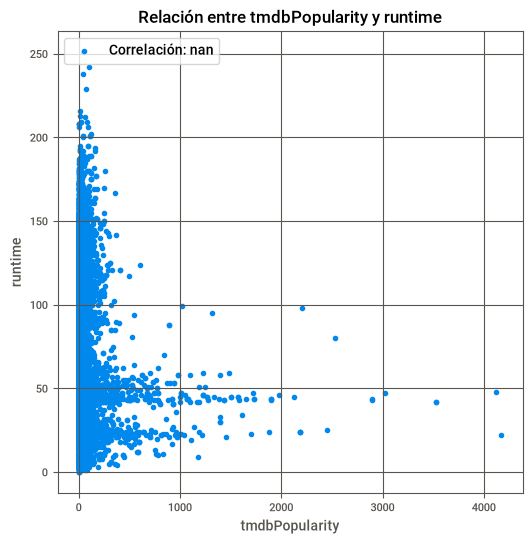

<h3>Inciso d)

<span style="color:violet">Ordenar las plataformas de streaming según diferentes criterios de
conveniencia, a determinar por uds mismos.</span>

- <span style="color:orange">Cuales son las plataformas, que en promedio, tienen la mejor rnk_rating?</span>
    <p>Donde rnk_rating es una ponderacion del 70% de imdbScore con un 30% de imdbVotes llevado a escala [1, 10] a traves de escala logaritmica

platform
Apple TV Plus         6.482214
Max                   6.254675
Disney Plus           6.252962
Netflix               6.030112
Paramount Plus        5.967747
Amazon Prime Video    5.522202
Name: rnk_rating, dtype: float64


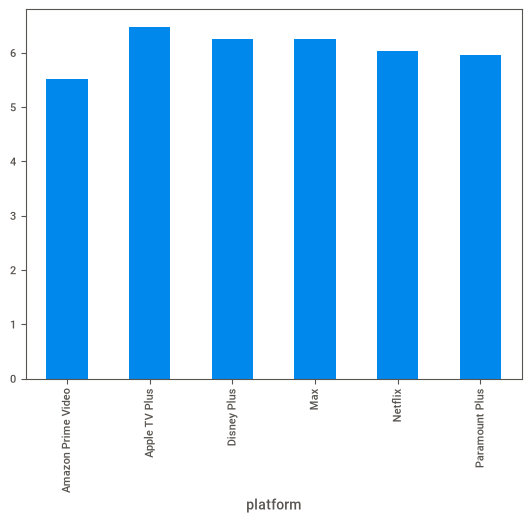

In [46]:
log_votos = np.log10(df['imdbVotes']+1)
min_log = log_votos.min()
max_log = log_votos.max()
df['votes_scaled'] = 10 * ((log_votos - min_log) / (max_log - min_log))
df['rnk_rating'] = (0.7 * df['imdbScore']) + (0.3 * df['votes_scaled'])

df.sort_values(by='rnk_rating', ascending=False)

grouped_data = df.groupby('platform')
median_platform = grouped_data['rnk_rating'].median()
grouped_data['rnk_rating'].median().plot(kind='bar')
print(median_platform.sort_values(ascending=False))
#media_platfrom es una serie (key, valor): (platform, media_rnk_rating)

- <span style="color:orange">Cuales son las plataformas, que mas tienen peliculas de Drama?</span>

platform
Netflix               3653
Amazon Prime Video    3350
Disney Plus           1080
Max                   1047
Paramount Plus         157
Apple TV Plus          102
Name: count, dtype: int64


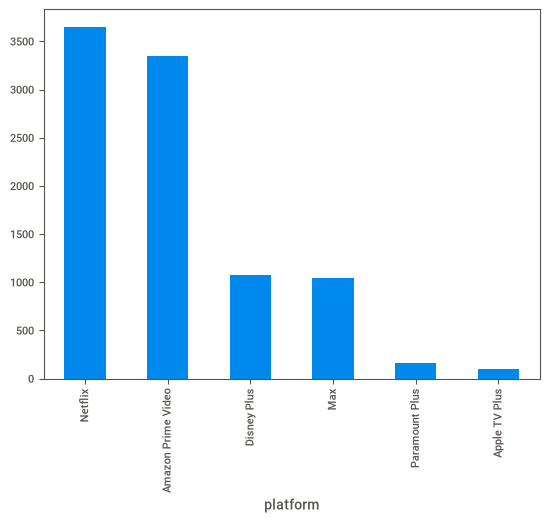

In [ ]:
max_terror = df[df['genres'].str.contains('Drama', case=False, na=False)]
print(max_terror['platform'].value_counts()) #cuenta cuantas veces aparece el atributo 'platform' en el dataset para cada valor.
#group by sirve para aplicar funciones de agregacion sobre eso luego.
max_terror['platform'].value_counts().plot(kind='bar')
plt.show()

- <span style="color:orange">Cuales son las plataformas, que mas peliculas tienen estrenadas en los ultimos n anios?</span>

platform
Netflix               3295
Amazon Prime Video    1391
Disney Plus            852
Max                    439
Name: count, dtype: int64


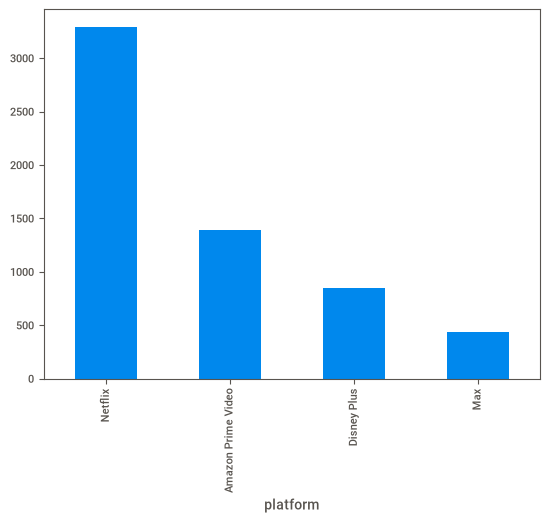

In [54]:
import datetime as d
year = d.date.today().year

def getMoviesLastYears(n):
    peliculas = df[df['year_init'] >= (year - n)]
    peliculas = peliculas['platform'].value_counts()
    peliculas.plot(kind='bar')
    print(peliculas)
    plt.show()

getMoviesLastYears(5)